# ***Custom Grid Setup(static)***

---



---



In [78]:
#Grid Size
ROWS = 5
COLS = 5

In [79]:
#Empty grid
grid = [['-' for _ in range(COLS)] for _ in range(ROWS)]

In [80]:
grid

[['-', '-', '-', '-', '-'],
 ['-', '-', '-', '-', '-'],
 ['-', '-', '-', '-', '-'],
 ['-', '-', '-', '-', '-'],
 ['-', '-', '-', '-', '-']]

In [81]:
grid[0][0] = 'S'   # Start
grid[0][1] = 'B'   # Button
grid[0][2] = 'M'   # Menu
grid[0][3] = 'F'   # Form
grid[2][2] = 'C'   # Crash (bug)
grid[3][4] = 'G'   # Goal
grid[4][4] = 'E'   # Exit

In [82]:
blocked = [(0,4),(1,4),(2,4),(4,0),(4,1),(4,2),(4,3)]
for r,c in blocked:
    grid[r][c] = 'X'

In [83]:
for row in grid:
    print(row)

['S', 'B', 'M', 'F', 'X']
['-', '-', '-', '-', 'X']
['-', '-', 'C', '-', 'X']
['-', '-', '-', '-', 'G']
['X', 'X', 'X', 'X', 'E']


In [84]:
agent_pos = [0,0]   # start at S

In [85]:
actions = {
    0: (-1,0),  # up
    1: (1,0),   # down
    2: (0,-1),  # left
    3: (0,1)    # right
}

In [86]:
#Defining Moving Function

def move(pos, action):
    r, c = pos
    dr, dc = action
    new_r, new_c = r + dr, c + dc

    if 0 <= new_r < ROWS and 0 <= new_c < COLS:
        if grid[new_r][new_c] != 'X':
            return [new_r, new_c]

    return pos

# ***RL training on GUI Grid***

---



---


In [87]:
import numpy as np
import random

# -----------------------------
# 1. Create GUI Grid Environment
# -----------------------------
grid = [
['S','B','M','F','X'],
['-','-','-','-','X'],
['-','-','C','-','X'],
['-','-','-','-','G'],
['X','X','X','X','E']
]

ROWS = len(grid)
COLS = len(grid[0])

# -----------------------------
# 2. Actions
# -----------------------------
actions = {
    0: (-1,0),  # up
    1: (1,0),   # down
    2: (0,-1),  # left
    3: (0,1)    # right
}

# -----------------------------
# 3. Parameters
# -----------------------------
alpha = 0.1        # learning rate
gamma = 0.8        # discount factor
epsilon = 0.2      # exploration
episodes = 500

# -----------------------------
# 4. Q-table
# -----------------------------
Q = np.zeros((ROWS, COLS, len(actions)))

# -----------------------------
# 5. Reward Function
# -----------------------------
def get_reward(r, c):
    if grid[r][c] == 'C':   # crash/bug
        return 10
    elif grid[r][c] == 'G': # goal
        return 5
    elif grid[r][c] == 'X': # blocked
        return -2
    else:
        return -1

# -----------------------------
# 6. Move Agent
# -----------------------------
def move(r, c, action):
    dr, dc = actions[action]
    new_r = r + dr
    new_c = c + dc

    if 0 <= new_r < ROWS and 0 <= new_c < COLS:
        if grid[new_r][new_c] != 'X':
            return new_r, new_c

    return r, c

# -----------------------------
# 7. Training
# -----------------------------
for episode in range(episodes):

    r, c = 0, 0   # start at S

    for step in range(100):

        # epsilon-greedy
        if random.uniform(0,1) < epsilon:
            action = random.choice(list(actions.keys()))
        else:
            action = np.argmax(Q[r, c])

        new_r, new_c = move(r, c, action)

        reward = get_reward(new_r, new_c)

        # Q-learning update
        Q[r, c, action] = Q[r, c, action] + alpha * (
            reward + gamma * np.max(Q[new_r, new_c]) - Q[r, c, action]
        )

        r, c = new_r, new_c

        # stop if goal reached
        if grid[r][c] == 'G':
            break

# -----------------------------
# 8. Learned Policy
# -----------------------------
policy = np.full((ROWS, COLS), ' ')

symbols = {
    0: '↑',
    1: '↓',
    2: '←',
    3: '→'
}

for r in range(ROWS):
    for c in range(COLS):
        if grid[r][c] not in ['X','G','C']:
            best_action = np.argmax(Q[r,c])
            policy[r,c] = symbols[best_action]
        else:
            policy[r,c] = grid[r][c]

# -----------------------------
# 9. Print Results
# -----------------------------
print("Grid:")
for row in grid:
    print(row)

print("\nLearned Policy:")
for row in policy:
    print(row)

Grid:
['S', 'B', 'M', 'F', 'X']
['-', '-', '-', '-', 'X']
['-', '-', 'C', '-', 'X']
['-', '-', '-', '-', 'G']
['X', 'X', 'X', 'X', 'E']

Learned Policy:
['→' '→' '↓' '←' 'X']
['→' '→' '↓' '←' 'X']
['→' '→' 'C' '←' 'X']
['→' '→' '↑' '←' 'G']
['X' 'X' 'X' 'X' '↑']


In [88]:
import time
import numpy as np
import random

grid = [
['S','-','-','-','X'],
['-','-','-','-','X'],
['-','-','C','-','X'],
['-','-','-','-','G'],
['X','X','X','X','E']
]

ROWS, COLS = 5,5

actions = [( -1,0 ), (1,0), (0,-1), (0,1)]

def print_grid(r,c):
    for i in range(ROWS):
        row=""
        for j in range(COLS):
            if i==r and j==c:
                row+="A "
            else:
                row+=grid[i][j]+" "
        print(row)
    print()

r,c = 0,0

for step in range(10):
    print(f"Step {step}")
    print_grid(r,c)
    time.sleep(1)

    action = random.choice(actions)
    nr = r + action[0]
    nc = c + action[1]

    if 0<=nr<ROWS and 0<=nc<COLS and grid[nr][nc]!="X":
        r,c = nr,nc

Step 0
A - - - X 
- - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 1
A - - - X 
- - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 2
A - - - X 
- - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 3
A - - - X 
- - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 4
S - - - X 
A - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 5
S - - - X 
- A - - X 
- - C - X 
- - - - G 
X X X X E 

Step 6
S - - - X 
A - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 7
S - - - X 
- A - - X 
- - C - X 
- - - - G 
X X X X E 

Step 8
S - - - X 
A - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 9
S - - - X 
- A - - X 
- - C - X 
- - - - G 
X X X X E 



In [89]:
symbols = {0:'↑', 1:'↓', 2:'←', 3:'→'}

policy = []
for r in range(ROWS):
    row = []
    for c in range(COLS):
        if grid[r][c] in ['X','C','G','E']:
            row.append(grid[r][c])
        else:
            best = np.argmax(Q[r,c])
            row.append(symbols[best])
    policy.append(row)

for row in policy:
    print(row)

['→', '→', '↓', '←', 'X']
['→', '→', '↓', '←', 'X']
['→', '→', 'C', '←', 'X']
['→', '→', '↑', '←', 'G']
['X', 'X', 'X', 'X', 'E']


In [90]:
r,c = 0,0

for step in range(15):
    print("Step:", step, ": Position:", (r,c))
    action = np.argmax(Q[r,c])
    r,c = move(r,c,action)

    if grid[r][c] in ['C','G']:
        print("Reached:", grid[r][c])
        break

Step: 0 : Position: (0, 0)
Step: 1 : Position: (0, 1)
Step: 2 : Position: (0, 2)
Step: 3 : Position: (1, 2)
Reached: C


In [91]:
def steps_rl():
    r,c=0,0
    for i in range(50):
        action = np.argmax(Q[r,c])
        r,c = move(r,c,action)
        if grid[r][c] in ['C','G']:
            return i
    return 50

print("Avg steps RL:", np.mean([steps_rl() for _ in range(50)]))

Avg steps RL: 3.0


In [92]:
def random_agent():
    r,c = 0,0
    total = 0
    for _ in range(50):
        action = random.randint(0,3)
        r,c = move(r,c,action)
        total += get_reward(r,c)
    return total

In [93]:
rl_scores = []
rand_scores = []

for _ in range(100):
    # RL
    r,c = 0,0
    total = 0
    for _ in range(50):
        action = np.argmax(Q[r,c])
        r,c = move(r,c,action)
        total += get_reward(r,c)
    rl_scores.append(total)

    rand_scores.append(random_agent())

print("RL avg:", np.mean(rl_scores))
print("Random avg:", np.mean(rand_scores))

RL avg: 214.0
Random avg: -12.47


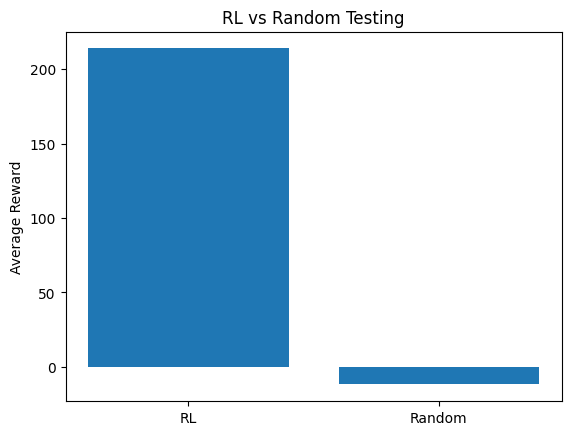

In [94]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(['RL','Random'], [214.0, -11.87])
plt.ylabel("Average Reward")
plt.title("RL vs Random Testing")
plt.show()

In [95]:
action = random.randint(0,3)

In [96]:
actions = [0,1,2,3]

In [97]:
action = random.choice(actions)

In [98]:
actions = {
    0: (-1,0),
    1: (1,0),
    2: (0,-1),
    3: (0,1)
}

In [99]:
action = random.choice(list(actions.keys()))

In [100]:
episode_rewards = []

In [101]:
for episode in range(episodes):

    r, c = 0, 0
    total_reward = 0

    for step in range(100):

        if random.uniform(0,1) < epsilon:
            action = random.choice(list(actions.keys()))
        else:
            action = np.argmax(Q[r, c])

        new_r, new_c = move(r, c, action)
        reward = get_reward(new_r, new_c)

        Q[r, c, action] = Q[r, c, action] + alpha * (
            reward + gamma * np.max(Q[new_r, new_c]) - Q[r, c, action]
        )

        r, c = new_r, new_c
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)

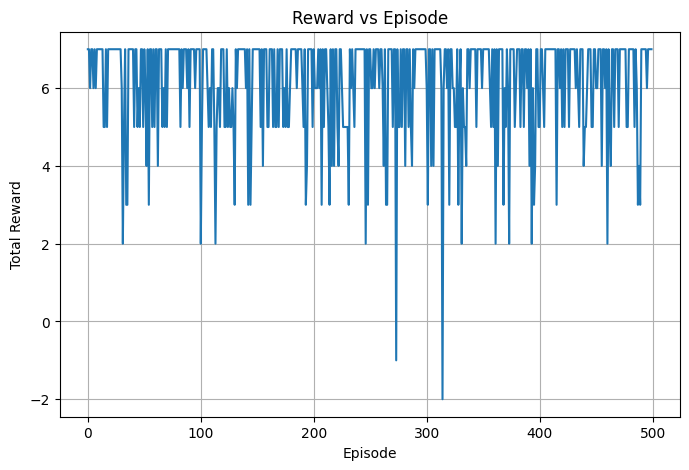

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(episode_rewards)
plt.grid()
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward vs Episode")
plt.show()

In [103]:
#epsilon = max(0.01, epsilon*0.995)

In [104]:
visited=set()
visited.add((r,c))

visited = set()

for episode in range(episodes):
    r,c = 0,0

    for step in range(50):

        visited.add((r,c))   # track visited state

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        r,c = move(r,c,action)

print("Unique states visited:", len(visited))

Unique states visited: 18


In [105]:
coverage = []
visited = set()

for episode in range(episodes):
    r,c = 0,0

    for step in range(50):
        visited.add((r,c))

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        r,c = move(r,c,action)

    coverage.append(len(visited))

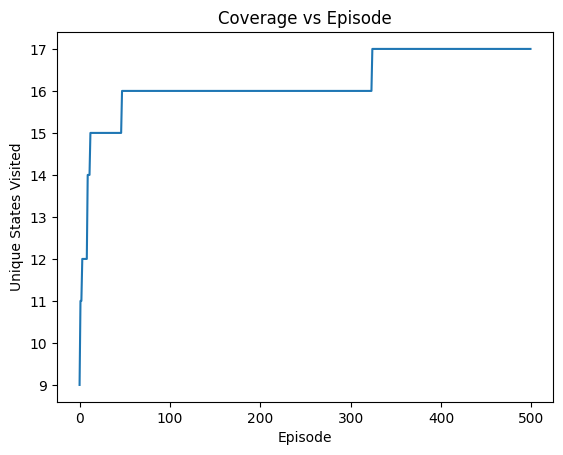

In [106]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(coverage)
plt.xlabel("Episode")
plt.ylabel("Unique States Visited")
plt.title("Coverage vs Episode")
plt.show()

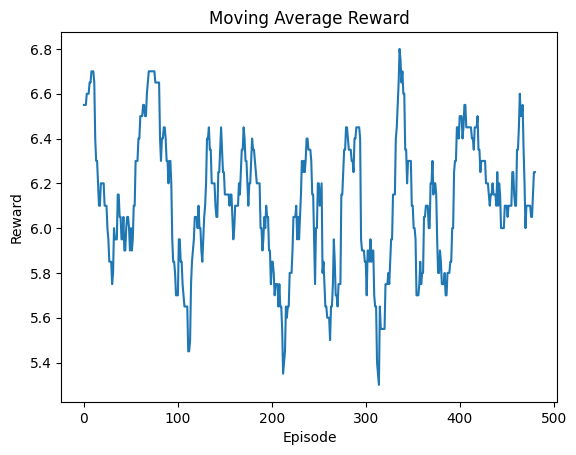

In [107]:
window = 20
moving_avg = np.convolve(episode_rewards,
                         np.ones(window)/window,
                         mode='valid')

plt.figure()
plt.plot(moving_avg)
plt.title("Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

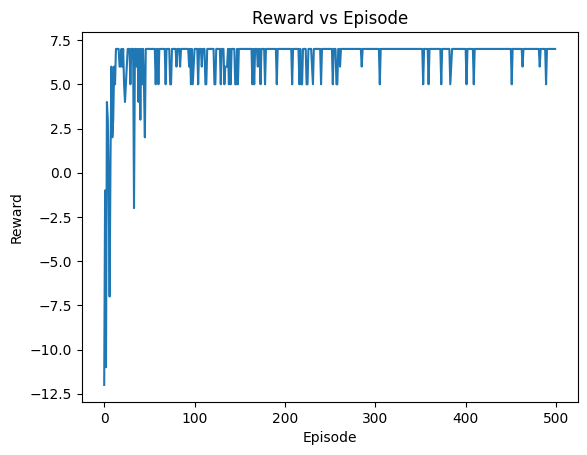

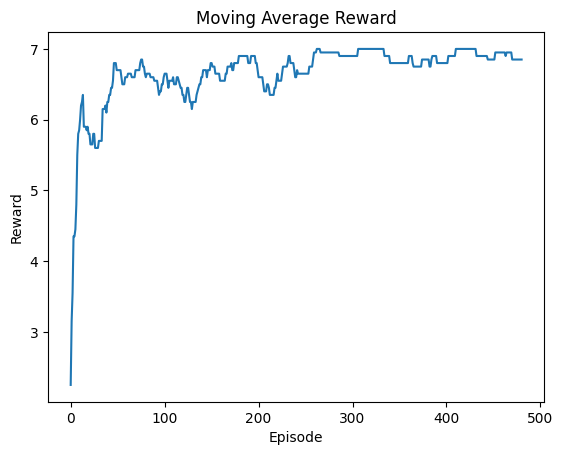

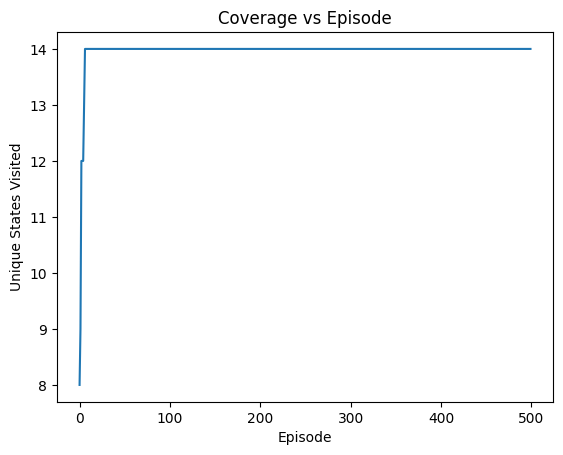

RL avg: 214.0
Random avg: -17.87
Avg steps RL: 3.0


In [108]:
import numpy as np
import random
import matplotlib.pyplot as plt

# -----------------------------
# GUI Grid
# -----------------------------
grid = [
['S','-','-','-','X'],
['-','-','-','-','X'],
['-','-','C','-','X'],
['-','-','-','-','G'],
['X','X','X','X','E']
]

ROWS = len(grid)
COLS = len(grid[0])

# -----------------------------
# Actions
# -----------------------------
actions = {
    0: (-1,0),   # up
    1: (1,0),    # down
    2: (0,-1),   # left
    3: (0,1)     # right
}

# -----------------------------
# Parameters
# -----------------------------
alpha = 0.1
gamma = 0.8
epsilon = 0.2
episodes = 500

Q = np.zeros((ROWS, COLS, 4))

# -----------------------------
# Reward function
# -----------------------------
def get_reward(r,c):
    if grid[r][c] == 'C':
        return 10
    elif grid[r][c] == 'G':
        return 5
    elif grid[r][c] == 'X':
        return -2
    else:
        return -1

# -----------------------------
# Move function
# -----------------------------
def move(r,c,action):
    dr,dc = actions[action]
    nr,nc = r+dr, c+dc

    if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr][nc] != 'X':
        return nr,nc
    return r,c

# -----------------------------
# Training
# -----------------------------
episode_rewards = []
coverage = []
visited = set()

for episode in range(episodes):

    r,c = 0,0
    total_reward = 0

    for step in range(50):

        visited.add((r,c))   # coverage tracking

        # epsilon-greedy
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr,nc = move(r,c,action)
        reward = get_reward(nr,nc)

        # Q update
        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r,c = nr,nc
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)
    coverage.append(len(visited))

    # epsilon decay
    epsilon = max(0.01, epsilon * 0.995)

# -----------------------------
# Plot Reward vs Episode
# -----------------------------
plt.figure()
plt.plot(episode_rewards)
plt.title("Reward vs Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# -----------------------------
# Moving Average
# -----------------------------
window = 20
moving_avg = np.convolve(
    episode_rewards,
    np.ones(window)/window,
    mode='valid'
)

plt.figure()
plt.plot(moving_avg)
plt.title("Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# -----------------------------
# Coverage Plot
# -----------------------------
plt.figure()
plt.plot(coverage)
plt.title("Coverage vs Episode")
plt.xlabel("Episode")
plt.ylabel("Unique States Visited")
plt.show()

# -----------------------------
# RL vs Random
# -----------------------------
def random_agent():
    r,c = 0,0
    total = 0
    for _ in range(50):
        action = random.randint(0,3)
        r,c = move(r,c,action)
        total += get_reward(r,c)
    return total

# RL evaluation
def rl_agent():
    r,c = 0,0
    total = 0
    for _ in range(50):
        action = np.argmax(Q[r,c])
        r,c = move(r,c,action)
        total += get_reward(r,c)
        if grid[r][c] in ['G']:
            break
    return total

rl_scores = [rl_agent() for _ in range(100)]
rand_scores = [random_agent() for _ in range(100)]

print("RL avg:", np.mean(rl_scores))
print("Random avg:", np.mean(rand_scores))

# -----------------------------
# Crash discovery speed
# -----------------------------
def steps_rl():
    r,c=0,0
    for i in range(50):
        action = np.argmax(Q[r,c])
        r,c = move(r,c,action)
        if grid[r][c] in ['C','G']:
            return i
    return 50

print("Avg steps RL:", np.mean([steps_rl() for _ in range(50)]))

In [109]:
symbols = {
    0: '↑',   # up
    1: '↓',   # down
    2: '←',   # left
    3: '→'    # right
}

print("\nOptimal Policy:\n")

for r in range(ROWS):
    row = []
    for c in range(COLS):

        if grid[r][c] == 'X':
            row.append('X')
        elif grid[r][c] == 'C':
            row.append('C')
        elif grid[r][c] == 'G':
            row.append('G')
        elif grid[r][c] == 'S':
            best_action = np.argmax(Q[r,c])
            row.append('S'+symbols[best_action])
        else:
            best_action = np.argmax(Q[r,c])
            row.append(symbols[best_action])

    print(row)


Optimal Policy:

['S↓', '↓', '↓', '←', 'X']
['→', '→', '↓', '←', 'X']
['→', '→', 'C', '↓', 'X']
['↓', '↑', '↑', '↑', 'G']
['X', 'X', 'X', 'X', '↑']


# ***Custom Grid Setup(dynamic)***

---



---

In [110]:
def randomize_environment():
    # remove C and G
    for r in range(ROWS):
        for c in range(COLS):
            if grid[r][c] in ['C','G']:
                grid[r][c] = '-'

    # place new crash
    while True:
        r = random.randint(0,ROWS-1)
        c = random.randint(0,COLS-1)
        if grid[r][c] == '-':
            grid[r][c] = 'C'
            break

    # place new goal
    while True:
        r = random.randint(0,ROWS-1)
        c = random.randint(0,COLS-1)
        if grid[r][c] == '-':
            grid[r][c] = 'G'
            break

In [111]:
if episode % 75 == 0:
    randomize_environment()

In [112]:
def print_grid(grid, episode):
    print("\nEnvironment changed at episode:", episode)
    for row in grid:
        print(row)

In [113]:
for episode in range(episodes):

    if episode % 75 == 0:
        randomize_environment()
        print_grid(grid, episode)

    r, c = 0, 0


Environment changed at episode: 0
['S', '-', '-', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', 'C', 'X']
['-', '-', 'G', '-', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 75
['S', 'G', '-', '-', 'X']
['C', '-', '-', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 150
['S', '-', '-', '-', 'X']
['-', 'C', '-', '-', 'X']
['-', 'G', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 225
['S', '-', '-', '-', 'X']
['-', '-', 'C', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', 'G', '-', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 300
['S', '-', '-', '-', 'X']
['-', '-', '-', 'C', 'X']
['G', '-', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 375
['S', '-', 'C', '-', 'X']
['-', '-', '-', 'G', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']



# ***RL training on (dynamic) GUI Grid***

---



---


In [114]:
episode_rewards = []

for episode in range(episodes):

    # change GUI dynamically
    if episode % 75 == 0:
        randomize_environment()


        # encourage re-exploration
        epsilon = 0.3

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        # epsilon-greedy
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        # Q-learning update
        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        # stop if crash or goal reached
        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)

    # decay epsilon
    epsilon = max(0.05, epsilon * 0.995)

In [115]:
symbols = {0:'↑',1:'↓',2:'←',3:'→'}

print("\nFinal Learned Policy:\n")

for r in range(ROWS):
    row = []
    for c in range(COLS):
        if grid[r][c] in ['X','C','G']:
            row.append(grid[r][c])
        else:
            row.append(symbols[np.argmax(Q[r,c])])
    print(row)


Final Learned Policy:

['↓', '↓', '↓', '←', 'X']
['→', '→', '↓', '←', 'X']
['↑', '↓', 'G', '↑', 'X']
['↑', 'C', '↑', '←', '↑']
['X', 'X', 'X', 'X', '↑']


In [116]:
import numpy as np
import random

# -----------------------------
# Dynamic randomization (your code)
# -----------------------------
def randomize_environment():
    # remove C and G
    for r in range(ROWS):
        for c in range(COLS):
            if grid[r][c] in ['C','G']:
                grid[r][c] = '-'

    # place new crash
    while True:
        r = random.randint(0,ROWS-1)
        c = random.randint(0,COLS-1)
        if grid[r][c] == '-':
            grid[r][c] = 'C'
            break

    # place new goal
    while True:
        r = random.randint(0,ROWS-1)
        c = random.randint(0,COLS-1)
        if grid[r][c] == '-':
            grid[r][c] = 'G'
            break


def print_grid(grid, episode):
    print("\nEnvironment changed at episode:", episode)
    for row in grid:
        print(row)


# -----------------------------
# Training
# -----------------------------
episode_rewards = []

for episode in range(episodes):

    # Print reward BEFORE changing environment
    if episode % 75 == 0 and episode > 0:
        avg_reward = np.mean(episode_rewards[-75:])
        print("\n--------------------------------")
        print("Average reward before change:", round(avg_reward,2))

        randomize_environment()
        print_grid(grid, episode)

        # encourage re-exploration
        epsilon = 0.3

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        # epsilon-greedy
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        # Q-learning update
        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        # stop if crash or goal reached
        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)

    # decay epsilon
    epsilon = max(0.05, epsilon * 0.995)


--------------------------------
Average reward before change: 1.15

Environment changed at episode: 75
['S', '-', '-', 'G', 'X']
['-', '-', '-', 'C', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

--------------------------------
Average reward before change: 3.77

Environment changed at episode: 150
['S', '-', '-', '-', 'X']
['-', '-', '-', 'G', 'X']
['C', '-', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

--------------------------------
Average reward before change: 2.63

Environment changed at episode: 225
['S', '-', '-', '-', 'X']
['G', 'C', '-', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

--------------------------------
Average reward before change: 5.03

Environment changed at episode: 300
['S', '-', '-', 'C', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', 'G', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

--------------------------------
Average reward before c

In [117]:
def print_policy(Q, grid, episode=None):
    symbols = {0:'↑',1:'↓',2:'←',3:'→'}

    if episode is not None:
        print("\nLearned policy at episode:", episode)

    for r in range(ROWS):
        row = []
        for c in range(COLS):

            if grid[r][c] == 'X':
                row.append('X')
            elif grid[r][c] == 'C':
                row.append('C')
            elif grid[r][c] == 'G':
                row.append('G')
            else:
                best_action = np.argmax(Q[r,c])
                row.append(symbols[best_action])

        print(row)

In [118]:
for episode in range(episodes):

    r, c = 0, 0

    for step in range(50):
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc

        if grid[r][c] in ['C','G']:
            break

    epsilon = max(0.05, epsilon*0.995)

    # change environment
    if episode % 75 == 0:
        randomize_environment()

    # show learned arrows
    if episode % 75 == 74:
        print_policy(Q, grid, episode)


Learned policy at episode: 74
['↓', '↓', '↓', '←', 'X']
['→', 'G', 'C', '↓', 'X']
['↑', '↑', '→', '↑', 'X']
['↑', '↑', '↑', '←', '↑']
['X', 'X', 'X', 'X', '↑']

Learned policy at episode: 149
['→', 'C', '→', '←', 'X']
['↑', '↑', '↓', '→', 'X']
['↑', '↑', '↑', '←', 'X']
['↑', 'G', '↑', '←', '↑']
['X', 'X', 'X', 'X', '↑']

Learned policy at episode: 224
['→', '→', 'C', '←', 'X']
['↑', '↓', '↑', '↑', 'X']
['↑', 'G', '→', '↑', 'X']
['↑', '↑', '↑', '←', '↑']
['X', 'X', 'X', 'X', '↑']

Learned policy at episode: 299
['↓', '↓', '↓', '←', 'X']
['C', '←', '←', '↓', 'X']
['↑', '↑', 'G', '↑', 'X']
['↑', '↑', '↑', '←', '↑']
['X', 'X', 'X', 'X', '↑']

Learned policy at episode: 374
['→', 'C', '↓', 'G', 'X']
['→', '↑', '←', '↓', 'X']
['↑', '↑', '→', '↑', 'X']
['↑', '↑', '↑', '←', '↑']
['X', 'X', 'X', 'X', '↑']

Learned policy at episode: 449
['↓', '←', '↓', '↓', 'X']
['↓', '→', '↓', '↓', 'X']
['↓', '→', '→', '↓', 'X']
['G', '↑', '↑', 'C', '↑']
['X', 'X', 'X', 'X', '↑']


In [119]:
change_points = []
episode_rewards = []

In [120]:
if episode % 75 == 0 and episode > 0:
    change_points.append(episode)

    avg_reward = np.mean(episode_rewards[-75:])
    print("Avg reward before change:", round(avg_reward,2))

    randomize_environment()
    print_grid(grid, episode)

    epsilon = 0.3

# ***Transfer learning (Testing on a diffrent GUI Grid)***

---



---


In [121]:
Q_transfer = Q.copy()

In [122]:
grid_B = [
['S','-','-','-','X'],
['X','X','-','X','X'],
['-','-','-','-','X'],
['-','C','-','-','G'],
['X','X','X','X','E']
]

In [123]:
Q = Q_transfer
epsilon = 0.3

transfer_rewards = []

for episode in range(500):

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    transfer_rewards.append(total_reward)
    epsilon = max(0.05, epsilon*0.995)

In [124]:
Q_scratch = np.zeros((ROWS,COLS,4))
epsilon = 0.3
scratch_rewards = []

for episode in range(100):

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q_scratch[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        Q_scratch[r,c,action] += alpha * (
            reward + gamma*np.max(Q_scratch[nr,nc]) - Q_scratch[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    scratch_rewards.append(total_reward)
    epsilon = max(0.05, epsilon*0.995)

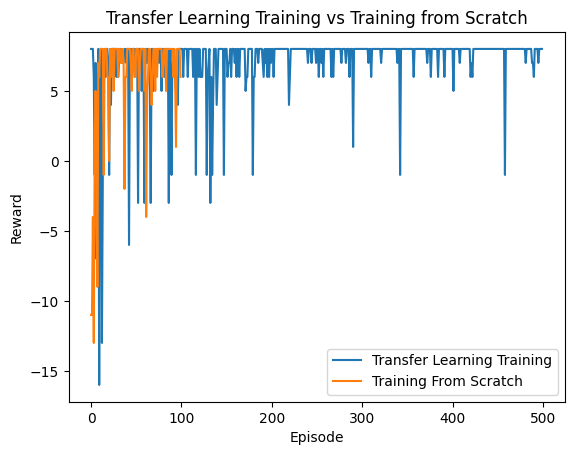

In [125]:
import matplotlib.pyplot as plt

plt.plot(transfer_rewards, label="Transfer Learning Training")
plt.plot(scratch_rewards, label="Training From Scratch")
plt.legend()
plt.title("Transfer Learning Training vs Training from Scratch")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

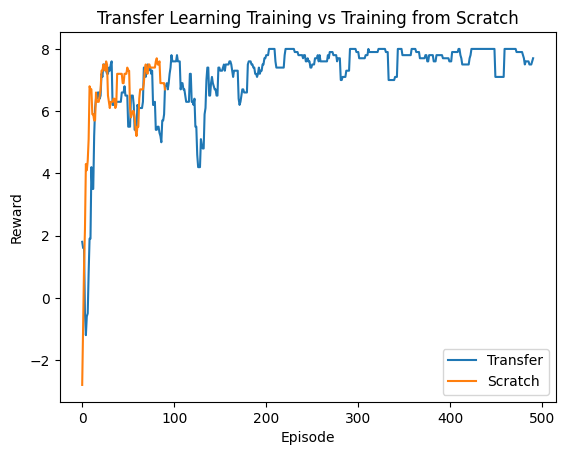

In [126]:
window = 10

transfer_smooth = np.convolve(
    transfer_rewards,
    np.ones(window)/window,
    mode='valid'
)

scratch_smooth = np.convolve(
    scratch_rewards,
    np.ones(window)/window,
    mode='valid'
)

import matplotlib.pyplot as plt

plt.plot(transfer_smooth, label="Transfer")
plt.plot(scratch_smooth, label="Scratch")
plt.legend()
plt.title("Transfer Learning Training vs Training from Scratch")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

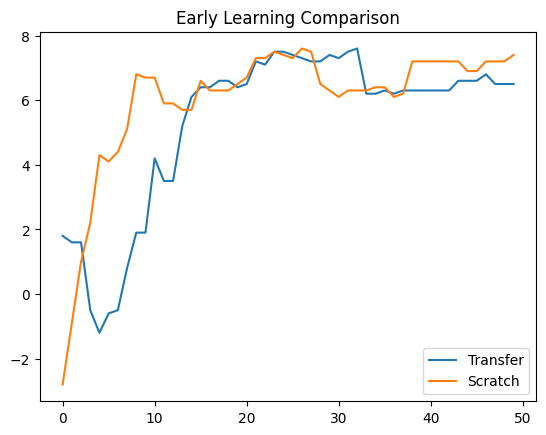

In [127]:
plt.plot(transfer_smooth[:50], label="Transfer")
plt.plot(scratch_smooth[:50], label="Scratch")
plt.legend()
plt.title("Early Learning Comparison")
plt.show()

In [128]:
print("Transfer avg first 50:",
      np.mean(transfer_rewards[:50]))

print("Scratch avg first 50:",
      np.mean(scratch_rewards[:50]))

Transfer avg first 50: 5.22
Scratch avg first 50: 4.78


In [129]:
threshold = 5

transfer_ep = next(i for i,v in enumerate(transfer_smooth) if v > threshold)
scratch_ep = next(i for i,v in enumerate(scratch_smooth) if v > threshold)

print("Transfer reaches threshold at:", transfer_ep)
print("Scratch reaches threshold at:", scratch_ep)

Transfer reaches threshold at: 13
Scratch reaches threshold at: 7


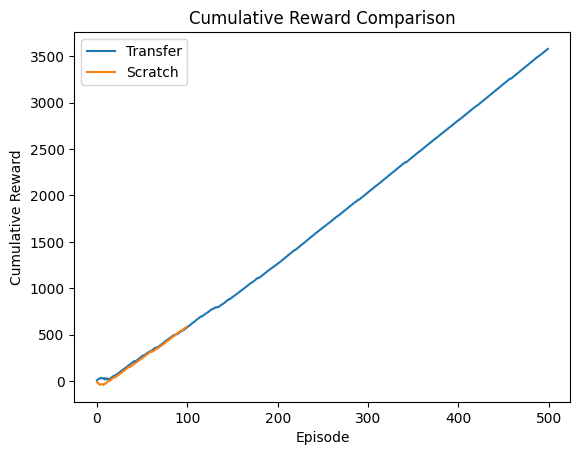

In [130]:
import numpy as np
import matplotlib.pyplot as plt

plt.plot(np.cumsum(transfer_rewards), label="Transfer")
plt.plot(np.cumsum(scratch_rewards), label="Scratch")
plt.legend()
plt.title("Cumulative Reward Comparison")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.show()

In [131]:
print("Transfer total first 50:",
      np.sum(transfer_rewards[:50]))

print("Scratch total first 50:",
      np.sum(scratch_rewards[:50]))

Transfer total first 50: 261
Scratch total first 50: 239


In [132]:
visit_count = np.zeros((ROWS, COLS))

# inside training loop
visit_count[r,c] += 1

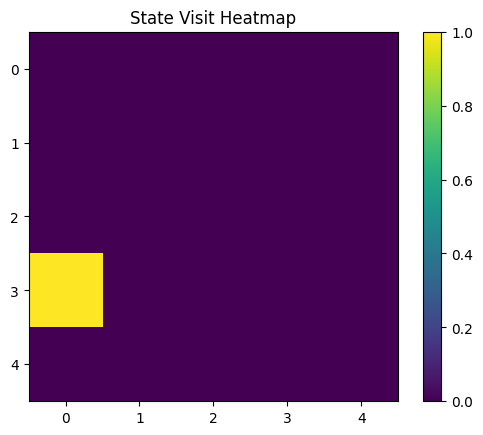

In [133]:
import matplotlib.pyplot as plt
plt.imshow(visit_count)
plt.title("State Visit Heatmap")
plt.colorbar()
plt.show()

In [134]:
#trying to addStochastic behaviour. following codes


In [135]:
def move(r, c, action):
    slip_prob = 0.15
    original_action = action

    if random.random() < slip_prob:
        action = random.randint(0,3)
        print(f"Slip! Intended: {original_action}, Actual: {action}")

    dr, dc = actions[action]
    nr = r + dr
    nc = c + dc

    if 0 <= nr < ROWS and 0 <= nc < COLS:
        if grid[nr][nc] != 'X':
            return nr, nc

    return r, c

In [136]:
episode_rewards = []

for episode in range(episodes):

    # change GUI dynamically
    if episode % 75 == 0:
        randomize_environment()
        epsilon = 0.3

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)

    epsilon = max(0.05, epsilon * 0.995)

Slip! Intended: 0, Actual: 0
Slip! Intended: 1, Actual: 1
Slip! Intended: 2, Actual: 0
Slip! Intended: 2, Actual: 0
Slip! Intended: 1, Actual: 1
Slip! Intended: 1, Actual: 2
Slip! Intended: 2, Actual: 2
Slip! Intended: 3, Actual: 2
Slip! Intended: 0, Actual: 2
Slip! Intended: 0, Actual: 2
Slip! Intended: 0, Actual: 2
Slip! Intended: 0, Actual: 3
Slip! Intended: 2, Actual: 3
Slip! Intended: 2, Actual: 1
Slip! Intended: 2, Actual: 1
Slip! Intended: 0, Actual: 3
Slip! Intended: 0, Actual: 2
Slip! Intended: 0, Actual: 0
Slip! Intended: 2, Actual: 2
Slip! Intended: 1, Actual: 1
Slip! Intended: 1, Actual: 1
Slip! Intended: 2, Actual: 3
Slip! Intended: 0, Actual: 1
Slip! Intended: 2, Actual: 1
Slip! Intended: 1, Actual: 3
Slip! Intended: 1, Actual: 1
Slip! Intended: 1, Actual: 2
Slip! Intended: 1, Actual: 1
Slip! Intended: 3, Actual: 2
Slip! Intended: 2, Actual: 2
Slip! Intended: 0, Actual: 2
Slip! Intended: 3, Actual: 1
Slip! Intended: 0, Actual: 1
Slip! Intended: 1, Actual: 0
Slip! Intended

In [137]:
import numpy as np
import random
import copy

# -----------------------------
# GRID
# -----------------------------
grid = [
['S','B','M','F','X'],
['-','-','-','-','X'],
['-','-','C','-','X'],
['-','-','-','-','G'],
['X','X','X','X','E']
]

ROWS = len(grid)
COLS = len(grid[0])

actions = {
    0: (-1,0),  # up
    1: (1,0),   # down
    2: (0,-1),  # left
    3: (0,1)    # right
}

symbols = {0:'↑',1:'↓',2:'←',3:'→'}

alpha = 0.1
gamma = 0.9
episodes = 500

# -----------------------------
# Reward
# -----------------------------
def get_reward(r, c):
    if grid[r][c] == 'C':
        return 10
    elif grid[r][c] == 'G':
        return 5
    elif grid[r][c] == 'X':
        return -2
    else:
        return -1

# -----------------------------
# Move (NO SLIP)
# -----------------------------
def move(r, c, action):
    dr, dc = actions[action]
    nr, nc = r + dr, c + dc

    if 0 <= nr < ROWS and 0 <= nc < COLS:
        if grid[nr][nc] != 'X':
            return nr, nc
    return r, c

# -----------------------------
# Move (WITH SLIP)
# -----------------------------
def move_with_slip(r, c, action, slip_prob=0.2):
    intended = action

    if random.random() < slip_prob:
        action = random.randint(0,3)  # random slip

    dr, dc = actions[action]
    nr, nc = r + dr, c + dc

    if 0 <= nr < ROWS and 0 <= nc < COLS:
        if grid[nr][nc] != 'X':
            return nr, nc
    return r, c

# -----------------------------
# TRAIN FUNCTION
# -----------------------------
def train(use_slip=False):
    Q = np.zeros((ROWS, COLS, 4))
    epsilon = 0.3

    for ep in range(episodes):
        r, c = 0, 0

        for step in range(100):

            if random.random() < epsilon:
                action = random.randint(0,3)
            else:
                action = np.argmax(Q[r,c])

            if use_slip:
                nr, nc = move_with_slip(r, c, action)
            else:
                nr, nc = move(r, c, action)

            reward = get_reward(nr, nc)

            Q[r,c,action] += alpha * (
                reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
            )

            r, c = nr, nc

            if grid[r][c] in ['C','G']:
                break

        epsilon = max(0.05, epsilon*0.995)

    return Q

# -----------------------------
# GET POLICY
# -----------------------------
def get_policy(Q):
    policy = np.full((ROWS, COLS), ' ')

    for r in range(ROWS):
        for c in range(COLS):
            if grid[r][c] in ['X','C','G']:
                policy[r,c] = grid[r][c]
            else:
                best = np.argmax(Q[r,c])
                policy[r,c] = symbols[best]

    return policy

# -----------------------------
# TRAIN BOTH
# -----------------------------
Q_no_slip = train(use_slip=False)
Q_slip = train(use_slip=True)

policy_no_slip = get_policy(Q_no_slip)
policy_slip = get_policy(Q_slip)

# -----------------------------
# PRINT
# -----------------------------
print("\n=== POLICY WITHOUT SLIP ===")
for row in policy_no_slip:
    print(row)

print("\n=== POLICY WITH SLIP ===")
for row in policy_slip:
    print(row)


=== POLICY WITHOUT SLIP ===
['→' '→' '↓' '←' 'X']
['→' '→' '↓' '←' 'X']
['→' '→' 'C' '↓' 'X']
['↑' '↓' '↑' '↑' 'G']
['X' 'X' 'X' 'X' '↑']

=== POLICY WITH SLIP ===
['→' '→' '↓' '←' 'X']
['→' '→' '↓' '←' 'X']
['→' '→' 'C' '←' 'X']
['→' '↑' '↑' '↑' 'G']
['X' 'X' 'X' 'X' '↑']


In [138]:
slip_count = 0
total_moves = 0

In [139]:
def move(r, c, action):
    global slip_count, total_moves
    total_moves += 1

    if random.random() < 0.15:
        slip_count += 1
        action = random.randint(0,3)

***Phase 2: Transfer Phase (Grid -> Web)***

In [140]:
!pip install selenium webdriver-manager


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [141]:
# =============================
# 1. IMPORTS
# =============================
import numpy as np
import random
import time

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.common.exceptions import (
    UnexpectedAlertPresentException,
    NoAlertPresentException,
    StaleElementReferenceException
)

# =============================
# 2. ALERT HANDLER
# =============================
def handle_alert(driver):
    try:
        alert = driver.switch_to.alert
        print("⚠ Alert detected:", alert.text)
        alert.accept()
        time.sleep(1)
        return True
    except NoAlertPresentException:
        return False

# =============================
# 3. SAFE CLICK FUNCTION
# =============================
def safe_click(driver, element):
    try:
        element.click()
        time.sleep(1)
        return True
    except UnexpectedAlertPresentException:
        handle_alert(driver)
        return True
    except StaleElementReferenceException:
        print("Element became stale")
        return False
    except Exception as e:
        print("Click error:", e)
        return False

# =============================
# 4. STATE EXTRACTION (Web → RL)
# =============================
def get_state(driver):
    """
    Convert webpage into RL state (r, c)
    Simple heuristic:
    - Count buttons and links
    - Map into small grid
    """
    buttons = driver.find_elements(By.TAG_NAME, "button")
    links = driver.find_elements(By.TAG_NAME, "a")

    r = min(len(buttons), 4)
    c = min(len(links), 4)

    return r, c

# =============================
# 5. ACTION MAPPING
# =============================
def get_action_elements(driver):
    """
    Map RL actions → clickable elements
    """
    elements = driver.find_elements(By.XPATH, "//button | //a")

    if len(elements) == 0:
        return None

    return elements

# =============================
# 6. LOAD TRAINED Q TABLE
# =============================
# 👉 Replace this with your trained Q-table
# Example dummy (5x5 grid, 4 actions)
Q = np.random.rand(5, 5, 4)

# =============================
# 7. WEB RL AGENT
# =============================
def run_web_agent(Q, url, steps=20):

    driver = webdriver.Chrome()
    driver.get(url)

    time.sleep(2)

    for step in range(steps):

        print(f"\n===== STEP {step+1} =====")

        # Get current state
        r, c = get_state(driver)
        print("State:", (r, c))

        # Choose action from Q-table
        action = np.argmax(Q[r, c])
        print("Chosen Action:", action)

        # Get elements
        elements = get_action_elements(driver)

        if not elements:
            print("No clickable elements found")
            break

        # Map action → element
        element = elements[action % len(elements)]

        # Perform action
        success = safe_click(driver, element)

        # Handle alert (IMPORTANT FIX)
        handle_alert(driver)

        if success:
            try:
                print("Clicked:", element.tag_name)
            except UnexpectedAlertPresentException:
                print("Alert interrupted tag fetch")
        else:
            print("Click failed")

        time.sleep(1)

    driver.quit()

# =============================
# 8. RUN
# =============================

# Simple test page (with alert)
TARGET_URL = "data:text/html,<h1>Test Page</h1><button onclick='alert(1)'>Click Me</button>"

run_web_agent(Q, TARGET_URL, steps=10)


===== STEP 1 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button

===== STEP 2 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button

===== STEP 3 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button

===== STEP 4 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button

===== STEP 5 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button

===== STEP 6 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button

===== STEP 7 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button

===== STEP 8 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button

===== STEP 9 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button

===== STEP 10 =====
State: (1, 0)
Chosen Action: 3
⚠ Alert detected: 1
Clicked: button


In [142]:
# =============================
# 1. IMPORTS
# =============================
import numpy as np
import random
import time

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.common.exceptions import NoAlertPresentException

# =============================
# 2. PARAMETERS
# =============================
alpha = 0.1
gamma = 0.9
epsilon = 0.3
episodes = 50
steps_per_episode = 10

# States: 3 (State 0,1,2)
# Actions: 2 (Click button A or B)
Q = np.zeros((3, 2))

# =============================
# 3. CREATE DYNAMIC WEB ENV
# =============================
HTML_ENV = """
data:text/html,
<html>
<body>

<h1 id="state">State 0</h1>

<button onclick="
let s = document.getElementById('state');
if(s.innerHTML=='State 0'){s.innerHTML='State 1';}
else if(s.innerHTML=='State 1'){s.innerHTML='State 2';}
">Go Forward</button>

<button onclick="
let s = document.getElementById('state');
if(s.innerHTML=='State 2'){s.innerHTML='State 1';}
else if(s.innerHTML=='State 1'){s.innerHTML='State 0';}
">Go Back</button>

</body>
</html>
"""

# =============================
# 4. STATE DETECTION
# =============================
def get_state(driver):
    text = driver.find_element(By.ID, "state").text
    
    if "State 0" in text:
        return 0
    elif "State 1" in text:
        return 1
    elif "State 2" in text:
        return 2

# =============================
# 5. REWARD FUNCTION
# =============================
def get_reward(state):
    if state == 2:
        return 10   # goal
    elif state == 1:
        return -1
    else:
        return -2

# =============================
# 6. ACTION EXECUTION
# =============================
def take_action(driver, action):
    buttons = driver.find_elements(By.TAG_NAME, "button")
    
    if action < len(buttons):
        buttons[action].click()
        time.sleep(0.5)

# =============================
# 7. TRAINING ON WEB
# =============================
driver = webdriver.Chrome()

for ep in range(episodes):
    
    driver.get(HTML_ENV)
    time.sleep(1)
    
    state = get_state(driver)
    total_reward = 0

    print(f"\n=== Episode {ep+1} ===")

    for step in range(steps_per_episode):

        # epsilon-greedy
        if random.random() < epsilon:
            action = random.randint(0,1)
        else:
            action = np.argmax(Q[state])

        print(f"State: {state}, Action: {action}")

        # perform action
        take_action(driver, action)

        # observe new state
        new_state = get_state(driver)
        reward = get_reward(new_state)

        print(f"New State: {new_state}, Reward: {reward}")

        # Q-learning update
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[new_state]) - Q[state, action]
        )

        state = new_state
        total_reward += reward

        # stop if goal reached
        if state == 2:
            print("Reached Goal!")
            break

    print("Total Reward:", total_reward)

    # decay epsilon
    epsilon = max(0.05, epsilon * 0.95)

driver.quit()

# =============================
# 8. FINAL POLICY
# =============================
print("\nFinal Q-table:\n", Q)

policy = np.argmax(Q, axis=1)
print("Learned Policy (0=Forward, 1=Back):", policy)


=== Episode 1 ===
State: 0, Action: 0
New State: 1, Reward: -1
State: 1, Action: 0
New State: 2, Reward: 10
Reached Goal!
Total Reward: 9

=== Episode 2 ===
State: 0, Action: 1
New State: 0, Reward: -2
State: 0, Action: 0
New State: 1, Reward: -1
State: 1, Action: 0
New State: 2, Reward: 10
Reached Goal!
Total Reward: 7

=== Episode 3 ===
State: 0, Action: 1
New State: 0, Reward: -2
State: 0, Action: 1
New State: 0, Reward: -2
State: 0, Action: 0
New State: 1, Reward: -1
State: 1, Action: 0
New State: 2, Reward: 10
Reached Goal!
Total Reward: 5

=== Episode 4 ===
State: 0, Action: 0
New State: 1, Reward: -1
State: 1, Action: 0
New State: 2, Reward: 10
Reached Goal!
Total Reward: 9

=== Episode 5 ===
State: 0, Action: 0
New State: 1, Reward: -1
State: 1, Action: 0
New State: 2, Reward: 10
Reached Goal!
Total Reward: 9

=== Episode 6 ===
State: 0, Action: 0
New State: 1, Reward: -1
State: 1, Action: 0
New State: 2, Reward: 10
Reached Goal!
Total Reward: 9

=== Episode 7 ===
State: 0, Ac

In [143]:
pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [144]:
URL = "data:text/html,\
<h1>RL Test Page</h1>\
<button onclick='alert(1)'>Click Me</button>\
<button onclick='document.body.style.background=\"yellow\"'>Color</button>\
<a href='#'>Link</a>"

In [145]:
import time
import random
import numpy as np

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import *
from selenium.webdriver.common.alert import Alert

# =============================
# 1. SETUP DRIVER
# =============================
def create_driver():
    options = Options()
    options.add_argument("--start-maximized")
    return webdriver.Chrome(options=options)

# =============================
# 2. SAFE ALERT HANDLER
# =============================
def handle_alert(driver):
    try:
        alert = driver.switch_to.alert
        print("⚠ Alert detected:", alert.text)
        alert.accept()
        return True
    except:
        return False

# =============================
# 3. SAFE CLICK
# =============================
def safe_click(driver, element):
    try:
        element.click()
        return True
    except:
        handle_alert(driver)
        try:
            element.click()
            return True
        except:
            return False

# =============================
# 4. GET STATE
# =============================
def get_state(driver):
    try:
        buttons = driver.find_elements(By.TAG_NAME, "button")
        inputs = driver.find_elements(By.TAG_NAME, "input")
        links = driver.find_elements(By.TAG_NAME, "a")

        return np.array([
            len(buttons),
            len(inputs),
            len(links),
            len(driver.page_source) % 1000
        ], dtype=np.float32)

    except NoSuchWindowException:
        return None

# =============================
# 5. REWARD FUNCTION
# =============================
def get_reward(prev_state, new_state):
    if new_state is None:
        return -10  # window crashed

    if new_state[0] > prev_state[0]:
        return +5   # more buttons → exploration

    return -1

# =============================
# 6. RUN AGENT (DEMO VERSION)
# =============================
def run_web_agent_demo(Q, url, steps=15):

    driver = create_driver()
    driver.get(url)

    # 🔥 STEP 1: SHOW WEBSITE FIRST
    print("\n🌐 Showing website to user...")
    time.sleep(5)   # 👈 GIVE TIME TO VIEW PAGE

    print("\n🤖 Starting RL Agent...\n")

    state = get_state(driver)

    for step in range(steps):

        if state is None:
            print("❌ Window closed. Restarting...")
            break

        print(f"\n===== STEP {step+1} =====")
        print("State:", state)

        # greedy action (demo)
        action = random.randint(0,3)
        print("Chosen Action:", action)

        try:
            elements = driver.find_elements(By.TAG_NAME, "button")

            if elements:
                element = random.choice(elements)

                success = safe_click(driver, element)

                if success:
                    print("✅ Clicked:", element.tag_name)
                else:
                    print("❌ Click failed")

        except Exception as e:
            print("⚠ Error:", e)

        handle_alert(driver)

        new_state = get_state(driver)

        reward = get_reward(state, new_state)
        print("Reward:", reward)

        state = new_state

        time.sleep(2)   # 👈 SLOW FOR VISIBILITY

    driver.quit()

In [146]:
Q = np.zeros((5,5,4))  # dummy
run_web_agent_demo(Q, URL)


🌐 Showing website to user...

🤖 Starting RL Agent...


===== STEP 1 =====
State: [  2.   0.   0. 186.]
Chosen Action: 0
✅ Clicked: button
Reward: -1

===== STEP 2 =====
State: [  2.   0.   0. 214.]
Chosen Action: 1
⚠ Error: Alert Text: 1
Message: unexpected alert open: {Alert text : 1}
  (Session info: chrome=147.0.7727.138)
Stacktrace:
	chromedriver!GetHandleVerifier [0x7ff68845a8e5+14e45]
	chromedriver!GetHandleVerifier [0x7ff68845a950+14eb0]
	chromedriver!(No symbol) [0x7ff6881cd6ed]
	chromedriver!(No symbol) [0x7ff6882752d8]
	chromedriver!(No symbol) [0x7ff6882190e8]
	chromedriver!(No symbol) [0x7ff688219fc3]
	chromedriver!GetHandleVerifier [0x7ff688770149+32a6a9]
	chromedriver!GetHandleVerifier [0x7ff68876a715+324c75]
	chromedriver!GetHandleVerifier [0x7ff68878c012+346572]
	chromedriver!GetHandleVerifier [0x7ff688477cb5+32215]
	chromedriver!GetHandleVerifier [0x7ff68848087c+3addc]
	chromedriver!GetHandleVerifier [0x7ff6884640e4+1e644]
	chromedriver!GetHandleVerifier [0x7ff6884642

In [147]:
import time
import random
import numpy as np

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import *
from selenium.webdriver.common.alert import Alert

# =============================
# 1. DRIVER SETUP
# =============================
def create_driver():
    options = Options()
    options.add_argument("--start-maximized")
    return webdriver.Chrome(options=options)

# =============================
# 2. ALERT HANDLER
# =============================
def handle_alert(driver):
    try:
        alert = driver.switch_to.alert
        print("⚠ Alert detected:", alert.text)
        alert.accept()
        time.sleep(0.5)
        return True
    except:
        return False

# =============================
# 3. SAFE CLICK
# =============================
def safe_click(driver, element):

    # clear any previous alert
    handle_alert(driver)

    try:
        element.click()
        time.sleep(0.5)
        return True

    except UnexpectedAlertPresentException:
        print("⚠ Alert interrupted → handling...")
        handle_alert(driver)
        try:
            element.click()
            return True
        except:
            return False

    except Exception as e:
        print("❌ Click error:", e)
        return False

# =============================
# 4. STATE REPRESENTATION
# =============================
def get_state(driver):
    try:
        buttons = driver.find_elements(By.TAG_NAME, "button")
        inputs = driver.find_elements(By.TAG_NAME, "input")
        links = driver.find_elements(By.TAG_NAME, "a")

        return np.array([
            len(buttons),
            len(inputs),
            len(links),
            len(driver.page_source) % 1000
        ], dtype=np.float32)

    except NoSuchWindowException:
        return None

# =============================
# 5. REWARD FUNCTION (SMART)
# =============================
def get_reward(prev_state, new_state):
    if new_state is None:
        return -10

    # reward if page becomes more complex
    if new_state[3] > prev_state[3]:
        return +5

    # reward if new buttons appear
    if new_state[0] > prev_state[0]:
        return +3

    return -1

# =============================
# 6. ACTION SPACE
# =============================
def get_elements(driver):
    buttons = driver.find_elements(By.TAG_NAME, "button")
    return buttons

# =============================
# 7. TRAINING ON WEB (Q-LEARNING)
# =============================
def train_web_agent(url, episodes=5, steps=15):

    # Q-table: (state_dim approx discretized → simplified)
    Q = {}

    alpha = 0.1
    gamma = 0.9
    epsilon = 0.3

    driver = create_driver()

    print("\n🌐 Opening Website...")
    driver.get(url)
    time.sleep(5)

    for ep in range(episodes):

        print(f"\n====================")
        print(f"🚀 EPISODE {ep+1}")
        print(f"====================")

        state = tuple(get_state(driver))

        for step in range(steps):

            print(f"\n----- STEP {step+1} -----")

            handle_alert(driver)

            elements = get_elements(driver)

            if not elements:
                print("⚠ No elements to interact with")
                break

            # epsilon-greedy
            if random.random() < epsilon:
                action = random.randint(0, len(elements)-1)
            else:
                action = np.argmax([Q.get((state, i), 0) for i in range(len(elements))])

            print("Chosen Action:", action)

            element = elements[action]

            success = safe_click(driver, element)

            if success:
                print("✅ Clicked button")
            else:
                print("❌ Click failed")

            handle_alert(driver)

            new_state_arr = get_state(driver)

            if new_state_arr is None:
                print("❌ Window closed!")
                break

            new_state = tuple(new_state_arr)

            reward = get_reward(np.array(state), np.array(new_state))
            print("Reward:", reward)

            # Q-update
            old_value = Q.get((state, action), 0)
            future = max([Q.get((new_state, a), 0) for a in range(len(elements))], default=0)

            Q[(state, action)] = old_value + alpha * (reward + gamma * future - old_value)

            state = new_state

            time.sleep(1.5)

        epsilon = max(0.05, epsilon * 0.9)

    driver.quit()

    return Q

# =============================
# 8. TEST PAGE (IMPORTANT)
# =============================
URL = "data:text/html,\
<h1>RL Learning Page</h1>\
<button onclick='document.body.innerHTML += \"<p>New Element</p>\"'>Add Content</button>\
<button onclick='alert(\"Penalty\")'>Bad Action</button>\
<button onclick='document.body.style.background=\"lightblue\"'>Change Color</button>"

# =============================
# 9. RUN
# =============================
Q = train_web_agent(URL, episodes=3, steps=10)


🌐 Opening Website...

🚀 EPISODE 1

----- STEP 1 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 2 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 3 -----
Chosen Action: 2
✅ Clicked button
Reward: 5

----- STEP 4 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 5 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 6 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 7 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 8 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 9 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 10 -----
Chosen Action: 2
✅ Clicked button
Reward: -1

🚀 EPISODE 2

----- STEP 1 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 2 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 3 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 4 -----
Chosen Action: 0
✅ Clicked button
Reward: 5

----- STEP 5 -----
Chosen Action: 0
✅ Clicked button


In [148]:
#login setup

URL = "data:text/html,\
<h2>Login Page</h2>\
<input id='username' placeholder='Username'><br><br>\
<input id='password' type='password' placeholder='Password'><br><br>\
<button onclick='login()'>Login</button>\
<p id='msg'></p>\
<script>\
function login(){\
var u=document.getElementById(\"username\").value;\
var p=document.getElementById(\"password\").value;\
if(u==\"admin\" && p==\"1234\"){\
document.getElementById(\"msg\").innerHTML=\"SUCCESS\";\
document.body.style.background=\"lightgreen\";\
}else{\
document.getElementById(\"msg\").innerHTML=\"FAIL\";\
alert(\"Wrong credentials\");\
}}\
</script>"

In [149]:
import time
import random
import numpy as np

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options

# =============================
# DRIVER
# =============================
def create_driver():
    options = Options()
    options.add_argument("--start-maximized")
    return webdriver.Chrome(options=options)

# =============================
# ALERT HANDLER
# =============================
def handle_alert(driver):
    try:
        alert = driver.switch_to.alert
        print("⚠ Alert:", alert.text)
        alert.accept()
        time.sleep(0.5)
    except:
        pass

# =============================
# STATE
# =============================
def get_state(driver):
    inputs = driver.find_elements(By.TAG_NAME, "input")
    buttons = driver.find_elements(By.TAG_NAME, "button")

    success = "SUCCESS" in driver.page_source

    return (len(inputs), len(buttons), success)

# =============================
# ACTIONS
# =============================
def perform_action(driver, action):

    inputs = driver.find_elements(By.TAG_NAME, "input")
    buttons = driver.find_elements(By.TAG_NAME, "button")

    if action == 0:
        inputs[0].clear()
        inputs[0].send_keys(random.choice(["admin", "user", "test"]))

    elif action == 1:
        inputs[1].clear()
        inputs[1].send_keys(random.choice(["1234", "0000", "pass"]))

    elif action == 2:
        buttons[0].click()

# =============================
# REWARD
# =============================
def get_reward(prev_state, new_state):
    if new_state[2]:  # success
        return +10
    return -1

# =============================
# TRAIN
# =============================
def train_login_agent(url, episodes=10, steps=10):

    Q = {}
    alpha = 0.1
    gamma = 0.9
    epsilon = 0.3

    driver = create_driver()
    driver.get(url)
    time.sleep(3)

    for ep in range(episodes):

        print(f"\n🚀 Episode {ep+1}")

        driver.refresh()
        time.sleep(1)

        state = get_state(driver)

        for step in range(steps):

            handle_alert(driver)

            if random.random() < epsilon:
                action = random.randint(0,2)
            else:
                action = np.argmax([Q.get((state,a),0) for a in range(3)])

            print("Action:", action)

            perform_action(driver, action)

            handle_alert(driver)

            new_state = get_state(driver)

            reward = get_reward(state, new_state)
            print("Reward:", reward)

            old = Q.get((state,action),0)
            future = max([Q.get((new_state,a),0) for a in range(3)])

            Q[(state,action)] = old + alpha*(reward + gamma*future - old)

            state = new_state

            if new_state[2]:  # success
                print("✅ LOGIN SUCCESS")
                break

            time.sleep(1)

        epsilon = max(0.05, epsilon * 0.9)

    driver.quit()
    return Q

In [150]:
import os

In [151]:
file_path = os.path.abspath("C:/Users/Pritam/Downloads/login_demo.html")  # already uploaded
URL = "file://" + file_path

In [152]:
import numpy as np
import random
import time
import os

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.alert import Alert

# -----------------------------
# 1. RL PARAMETERS
# -----------------------------
alpha = 0.1
gamma = 0.9
epsilon = 0.5
episodes = 30

# Q-table: (user_filled, pass_filled, page_state, actions)
Q = np.zeros((2, 2, 2, 4))  # reduced clean state

# -----------------------------
# 2. FILE PATH (EDIT THIS)
# -----------------------------
file_path = os.path.abspath("C:/Users/Niladri Banerjee/Downloads/login_demo.html")  # already uploaded
URL = "file://" + file_path

# -----------------------------
# 3. START BROWSER
# -----------------------------
driver = webdriver.Chrome()

# -----------------------------
# 4. STATE FUNCTION
# -----------------------------
def get_state():
    try:
        user_elem = driver.find_element(By.ID, "user")
        pass_elem = driver.find_element(By.ID, "pass")

        user = user_elem.get_attribute("value")
        pwd = pass_elem.get_attribute("value")

        return (int(len(user) > 0), int(len(pwd) > 0), 0)

    except:
        # if inputs not found → success page
        return (1, 1, 1)

# -----------------------------
# 5. SUCCESS CHECK
# -----------------------------
def is_success():
    return "Login Success" in driver.page_source and \
           len(driver.find_elements(By.ID, "user")) == 0

# -----------------------------
# 6. ACTION FUNCTION
# -----------------------------
def take_action(action):

    try:
        # 0 → fill username
        if action == 0:
            elem = driver.find_element(By.ID, "user")
            if elem.get_attribute("value") == "":
                elem.send_keys("admin")
                return 2   # reward for correct step
            else:
                return -1

        # 1 → fill password
        elif action == 1:
            elem = driver.find_element(By.ID, "pass")
            if elem.get_attribute("value") == "":
                elem.send_keys("1234")
                return 2
            else:
                return -1

        # 2 → click login
        elif action == 2:
            user = driver.find_element(By.ID, "user").get_attribute("value")
            pwd = driver.find_element(By.ID, "pass").get_attribute("value")

            if user and pwd:
                driver.find_element(By.TAG_NAME, "button").click()
                time.sleep(0.5)

                if is_success():
                    return 20   # SUCCESS
                else:
                    return -5   # wrong credentials

            else:
                return -5  # premature click

        # 3 → do nothing
        elif action == 3:
            return -2

    except:
        # handle alert
        try:
            alert = Alert(driver)
            print("⚠ Alert:", alert.text)
            alert.accept()
            return -10
        except:
            return -5

# -----------------------------
# 7. TRAINING LOOP
# -----------------------------
for ep in range(episodes):

    print("\n====================")
    print(f"🚀 EPISODE {ep+1}")
    print("====================")

    # RESET ENVIRONMENT PROPERLY
    driver.get(URL)
    time.sleep(1)
    driver.delete_all_cookies()
    driver.refresh()
    time.sleep(1)

    for step in range(10):

        state = get_state()

        # epsilon-greedy
        if random.random() < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[state])

        print(f"\nSTEP {step+1}")
        print("State:", state)
        print("Action:", action)

        reward = take_action(action)

        new_state = get_state()

        # Q-learning update
        Q[state][action] += alpha * (
            reward + gamma * np.max(Q[new_state]) - Q[state][action]
        )

        print("Reward:", reward)

        if reward == 20:
            print("🎯 SUCCESS PATH FOUND!")
            break

    # decay epsilon
    epsilon = max(0.05, epsilon * 0.9)

# -----------------------------
# 8. TEST TRAINED AGENT
# -----------------------------
print("\n🎯 TESTING TRAINED AGENT")

driver.get(URL)
time.sleep(1)

for step in range(5):

    state = get_state()
    action = np.argmax(Q[state])

    print(f"Step {step+1} | Action: {action}")

    reward = take_action(action)

    if reward == 20:
        print("✅ Agent successfully logged in!")
        break

driver.quit()


🚀 EPISODE 1

STEP 1
State: (1, 1, 1)
Action: 0
Reward: -5

STEP 2
State: (1, 1, 1)
Action: 1
Reward: -5

STEP 3
State: (1, 1, 1)
Action: 1
Reward: -5

STEP 4
State: (1, 1, 1)
Action: 2
Reward: -5

STEP 5
State: (1, 1, 1)
Action: 3
Reward: -2

STEP 6
State: (1, 1, 1)
Action: 2
Reward: -5

STEP 7
State: (1, 1, 1)
Action: 1
Reward: -5

STEP 8
State: (1, 1, 1)
Action: 2
Reward: -5

STEP 9
State: (1, 1, 1)
Action: 3
Reward: -2

STEP 10
State: (1, 1, 1)
Action: 3
Reward: -2

🚀 EPISODE 2

STEP 1
State: (1, 1, 1)
Action: 0
Reward: -5

STEP 2
State: (1, 1, 1)
Action: 3
Reward: -2

STEP 3
State: (1, 1, 1)
Action: 0
Reward: -5

STEP 4
State: (1, 1, 1)
Action: 3
Reward: -2

STEP 5
State: (1, 1, 1)
Action: 2
Reward: -5

STEP 6
State: (1, 1, 1)
Action: 3
Reward: -2

STEP 7
State: (1, 1, 1)
Action: 0
Reward: -5

STEP 8
State: (1, 1, 1)
Action: 3
Reward: -2

STEP 9
State: (1, 1, 1)
Action: 3
Reward: -2

STEP 10
State: (1, 1, 1)
Action: 1
Reward: -5

🚀 EPISODE 3

STEP 1
State: (1, 1, 1)
Action: 3
Rewa

In [153]:
file_path = os.path.abspath("C:/Users/Pritam/Downloads/login_demo.html")  # already uploaded
URL = "file://" + file_path

In [154]:
import time
import random
import numpy as np
import os

from selenium import webdriver
from selenium.webdriver.common.by import By

# ============================
# CONFIG
# ============================

file_path = os.path.abspath(
    "C:/Users/Pritam/Downloads/login_demo.html"
)
URL = "file://" + file_path

ACTIONS = 4  # 0:user, 1:pass, 2:wrong, 3:click

Q = {}

alpha = 0.3
gamma = 0.9

epsilon = 1.0
epsilon_decay = 0.90
epsilon_min = 0.05

episodes = 20
steps = 10

# ============================
# DRIVER
# ============================

driver = webdriver.Chrome()

# ============================
# Q TABLE
# ============================

def get_q(state):
    if state not in Q:
        Q[state] = np.zeros(ACTIONS)
    return Q[state]

# ============================
# STATE FUNCTION (FIXED + STABLE)
# ============================

def get_state(driver):
    """
    State = (username_correct, password_correct)
    NO fake 'SUCCESS' state anymore.
    """

    try:
        user = driver.find_element(By.ID, "user").get_attribute("value")
        password = driver.find_element(By.ID, "pass").get_attribute("value")

        return (
            int(user == "admin"),
            int(password == "1234")
        )

    except:
        return (-1, -1)  # invalid state

# ============================
# ACTION FUNCTION (FIXED REWARD LOGIC)
# ============================

def apply_action(driver, action):

    reward = -1
    done = False

    try:
        user_box = driver.find_element(By.ID, "user")
        pass_box = driver.find_element(By.ID, "pass")

        # -------------------------
        # ACTION 0: USERNAME
        # -------------------------
        if action == 0:
            print("⌨ Typing USERNAME: admin")
            user_box.clear()
            user_box.send_keys("admin")

        # -------------------------
        # ACTION 1: PASSWORD
        # -------------------------
        elif action == 1:
            print("⌨ Typing PASSWORD: 1234")
            pass_box.clear()
            pass_box.send_keys("1234")

        # -------------------------
        # ACTION 2: WRONG INPUT
        # -------------------------
        elif action == 2:
            print("❌ Typing WRONG credentials")
            user_box.clear()
            pass_box.clear()
            user_box.send_keys("wrong")
            pass_box.send_keys("wrong")

        # -------------------------
        # ACTION 3: LOGIN CLICK
        # -------------------------
        elif action == 3:
            print("🖱 Click LOGIN")
            driver.find_element(By.TAG_NAME, "button").click()

            time.sleep(0.5)

            # ✅ STRICT SUCCESS CONDITION
            user = driver.find_element(By.ID, "user").get_attribute("value")
            password = driver.find_element(By.ID, "pass").get_attribute("value")

            if user == "admin" and password == "1234":
                if "Login Success" in driver.page_source:
                    print("🎉 LOGIN SUCCESS!")
                    reward = 50
                    done = True
                else:
                    reward = -10
            else:
                print("🚫 LOGIN FAILED (wrong state)")
                reward = -10

    except:
        reward = -5

    return reward, done

# ============================
# TRAINING LOOP
# ============================

for ep in range(episodes):

    print("\n====================")
    print(f"🚀 EPISODE {ep+1}")
    print("====================")

    driver.get(URL)
    time.sleep(1)

    state = get_state(driver)
    get_q(state)

    for step in range(steps):

        print(f"\nSTEP {step+1}")
        print("State:", state)

        # epsilon-greedy
        if random.random() < epsilon:
            action = random.randint(0, ACTIONS - 1)
        else:
            action = np.argmax(get_q(state))

        print("Action:", action)

        reward, done = apply_action(driver, action)

        new_state = get_state(driver)

        print("Reward:", reward)

        # -------------------------
        # Q UPDATE
        # -------------------------
        q_values = get_q(state)
        next_q = get_q(new_state)

        q_values[action] += alpha * (
            reward + gamma * np.max(next_q) - q_values[action]
        )

        state = new_state

        if done:
            print("🏁 EPISODE SUCCESS")
            break

    # decay epsilon
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

# ============================
# TESTING
# ============================

print("\n🎯 TESTING TRAINED AGENT")

driver.get(URL)
time.sleep(1)

state = get_state(driver)

for step in range(10):

    action = np.argmax(get_q(state))

    print(f"\nTest Step {step+1} | Action:", action)

    reward, done = apply_action(driver, action)

    state = get_state(driver)

    if done:
        print("✅ FINAL: AGENT LOGGED IN SUCCESSFULLY")
        break

driver.quit()


🚀 EPISODE 1

STEP 1
State: (-1, -1)
Action: 2
Reward: -5

STEP 2
State: (-1, -1)
Action: 2
Reward: -5

STEP 3
State: (-1, -1)
Action: 3
Reward: -5

STEP 4
State: (-1, -1)
Action: 1
Reward: -5

STEP 5
State: (-1, -1)
Action: 2
Reward: -5

STEP 6
State: (-1, -1)
Action: 2
Reward: -5

STEP 7
State: (-1, -1)
Action: 1
Reward: -5

STEP 8
State: (-1, -1)
Action: 2
Reward: -5

STEP 9
State: (-1, -1)
Action: 1
Reward: -5

STEP 10
State: (-1, -1)
Action: 2
Reward: -5

🚀 EPISODE 2

STEP 1
State: (-1, -1)
Action: 0
Reward: -5

STEP 2
State: (-1, -1)
Action: 1
Reward: -5

STEP 3
State: (-1, -1)
Action: 3
Reward: -5

STEP 4
State: (-1, -1)
Action: 2
Reward: -5

STEP 5
State: (-1, -1)
Action: 1
Reward: -5

STEP 6
State: (-1, -1)
Action: 0
Reward: -5

STEP 7
State: (-1, -1)
Action: 3
Reward: -5

STEP 8
State: (-1, -1)
Action: 3
Reward: -5

STEP 9
State: (-1, -1)
Action: 0
Reward: -5

STEP 10
State: (-1, -1)
Action: 3
Reward: -5

🚀 EPISODE 3

STEP 1
State: (-1, -1)
Action: 2
Reward: -5

STEP 2
State:

In [155]:
#Extension to DQN

In [156]:
import time
import random
import numpy as np
import os

import torch
import torch.nn as nn
import torch.optim as optim

from collections import deque

from selenium import webdriver
from selenium.webdriver.common.by import By

In [159]:
import time
import numpy as np
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options


class LoginEnv:

    def __init__(self, url):
        self.url = url
        self.driver = self._create_driver()

    # -------------------------
    # SAFE DRIVER CREATION
    # -------------------------
    def _create_driver(self):

        options = Options()
        options.add_argument("--start-maximized")
        options.add_argument("--disable-dev-shm-usage")
        options.add_argument("--no-sandbox")

        driver = webdriver.Chrome(options=options)
        return driver

    # -------------------------
    # SAFE RESET (CRITICAL FIX)
    # -------------------------
    def reset(self):

        try:
            self.driver.quit()
        except:
            pass

        self.driver = self._create_driver()
        self.driver.get(self.url)
        time.sleep(1)

        return self.get_state()

    # -------------------------
    # STATE
    # -------------------------
    def get_state(self):
        try:
            if "Login Success" in self.driver.page_source:
                return np.array([1, 1, 1], dtype=np.float32)

            user = self.driver.find_element(By.ID, "user").get_attribute("value")
            pwd = self.driver.find_element(By.ID, "pass").get_attribute("value")

            return np.array([
                int(user == "admin"),      # 1 if correct username
                int(pwd == "1234"),        # 1 if correct password
                0                          # placeholder feature (can expand later)
            ], dtype=np.float32)
                      
        except:
            return np.array([0, 0, 0], dtype=np.float32)
        

    # -------------------------
    # STEP (CRASH SAFE)
    # -------------------------
    def step(self, action):

        reward = -1
        done = False

        try:
            user_box = self.driver.find_element(By.ID, "user")
            pass_box = self.driver.find_element(By.ID, "pass")

            # ---------------- USER ----------------
            if action == 0:
                user_box.clear()
                user_box.send_keys("admin")

            # ---------------- PASS ----------------
            elif action == 1:
                pass_box.clear()
                pass_box.send_keys("1234")

            # ---------------- WRONG ---------------
            elif action == 2:
                user_box.clear()
                pass_box.clear()
                user_box.send_keys("wrong")
                pass_box.send_keys("wrong")

            # ---------------- LOGIN --------------
            elif action == 3:

                self.driver.find_element(By.TAG_NAME, "button").click()
                time.sleep(0.5)

                if "Login Success" in self.driver.page_source:
                    reward = 50
                    done = True
                else:
                    reward = -10

        except Exception as e:

            # 🔥 AUTO RECOVERY (IMPORTANT)
            print("⚠ Driver crashed → restarting browser")

            self.driver = self._create_driver()
            self.driver.get(self.url)
            time.sleep(1)

            reward = -5
            done = False

        return self.get_state(), reward, done, {}

    # -------------------------
    # CLEAN EXIT
    # -------------------------
    def close(self):
        try:
            self.driver.quit()
        except:
            pass

In [160]:

import random
from collections import deque

In [161]:
class DQN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 64),   #  CHANGED: 2 → 3
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.net(x)

In [162]:
import os

file_path = os.path.abspath("C:/Users/Pritam/Downloads/login_demo.html")
url = "file://" + file_path

env = LoginEnv(url)

model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters(), lr=0.001)

buffer = deque(maxlen=10000)

gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.95
epsilon_min = 0.05

episodes = 50
batch_size = 32

In [163]:
import time
import numpy as np
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait


class LoginEnv:

    def __init__(self, url):
        self.url = url
        self.driver = webdriver.Chrome()
        self.wait = WebDriverWait(self.driver, 3)

    # ---------------- RESET (SAFE RECOVERY) ----------------
    def reset(self):
        try:
            self.driver.get(self.url)
            time.sleep(1)
        except Exception:
            # restart browser if crashed
            try:
                self.driver.quit()
            except:
                pass
            self.driver = webdriver.Chrome()
            self.driver.get(self.url)

        return self.get_state()

    # ---------------- STATE (FIXED + INFORMATIVE) ----------------
    def get_state(self):
        try:
            user = self.driver.find_element(By.ID, "user").get_attribute("value") or ""
            pwd = self.driver.find_element(By.ID, "pass").get_attribute("value") or ""

            page = self.driver.page_source.lower()

            return np.array([
                len(user),                      # 0
                len(pwd),                       # 1
                int(user == "admin"),          # 2
                int(pwd == "1234"),           # 3
                int("success" in page),        # 4
                int("login" in page)           # 5
            ], dtype=np.float32)

        except:
            return np.zeros(6, dtype=np.float32)

    # ---------------- STEP ----------------
    def step(self, action):

        reward = -1
        done = False

        user_box = self.driver.find_element(By.ID, "user")
        pass_box = self.driver.find_element(By.ID, "pass")

        user_val = user_box.get_attribute("value") or ""
        pass_val = pass_box.get_attribute("value") or ""

        # ---------------- ACTION 0 ----------------
        if action == 0:
            user_box.clear()
            user_box.send_keys("admin")
            reward = 2 if user_box.get_attribute("value") == "admin" else -1

        # ---------------- ACTION 1 ----------------
        elif action == 1:
            pass_box.clear()
            pass_box.send_keys("1234")
            reward = 2 if pass_box.get_attribute("value") == "1234" else -1

        # ---------------- ACTION 2 ----------------
        elif action == 2:
            user_box.clear()
            pass_box.clear()
            user_box.send_keys("wrong")
            pass_box.send_keys("wrong")
            reward = -2

        # ---------------- ACTION 3 (LOGIN) ----------------
        elif action == 3:

            # ❌ prevent invalid login attempt
            if user_val != "admin" or pass_val != "1234":
                return self.get_state(), -25, False, {}

            try:
                self.driver.find_element(By.TAG_NAME, "button").click()
                time.sleep(1.0)

                page = self.driver.page_source.lower()
                url = self.driver.current_url.lower()

                success = (
                    "success" in page or
                    "welcome" in page or
                    "dashboard" in page or
                    "logout" in page or
                    "/home" in url
                )

                if success:
                    reward = 100
                    done = True
                else:
                    reward = -30

            except:
                reward = -50
                done = False

        return self.get_state(), reward, done, {}

    def close(self):
        try:
            self.driver.quit()
        except:
            pass

In [164]:
import torch
import torch.nn as nn


class DQN(nn.Module):

    def __init__(self, state_size=6, action_size=4):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.net(x)

In [165]:
import random
from collections import deque
import torch.optim as optim

file_path = os.path.abspath(
    "C:/Users/Pritam/Downloads/login_demo.html"
)
URL = "file://" + file_path

env = LoginEnv(url)

model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters(), lr=0.001)

buffer = deque(maxlen=5000)

gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.97
epsilon_min = 0.05

episodes = 50
batch_size = 32

success_history = []

In [166]:
import gc

In [167]:
try:
    env.close()
except:
    pass

In [168]:
env = LoginEnv(url)

In [169]:
for ep in range(episodes):

    state = env.reset()
    total_reward = 0
    done = False

    for step in range(20):

        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

        # epsilon-greedy
        if random.random() < epsilon:
            action = random.randint(0, 3)
        else:
            with torch.no_grad():
                action = torch.argmax(model(state_t)).item()

        next_state, reward, done, _ = env.step(action)

        buffer.append((state, action, reward, next_state, done))

        state = next_state
        total_reward += reward

        # ---------------- TRAIN ----------------
        if len(buffer) > batch_size:

            batch = random.sample(buffer, batch_size)

            s, a, r, s2, d = map(np.array, zip(*batch))

            s = torch.tensor(s, dtype=torch.float32)
            s2 = torch.tensor(s2, dtype=torch.float32)
            a = torch.tensor(a, dtype=torch.int64)
            r = torch.tensor(r, dtype=torch.float32)
            d = torch.tensor(d, dtype=torch.float32)

            q_values = model(s).gather(1, a.unsqueeze(1)).squeeze()

            with torch.no_grad():
                next_q = target_model(s2).max(1)[0]
                target = r + gamma * next_q * (1 - d)

            loss = ((q_values - target) ** 2).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            success_history.append(1)
            break

    if not done:
        success_history.append(0)

    # target network update
    if ep % 5 == 0:
        target_model.load_state_dict(model.state_dict())

    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    print(
        f"Episode {ep+1} | Reward: {total_reward:.2f} | "
        f"Success Rate: {np.mean(success_history[-20:]):.2f}"
    )

    # =========================
    # 🧹 CLEANUP (IMPORTANT FIX)
    # =========================
    
    gc.collect()

NoSuchElementException: Message: no such element: Unable to locate element: {"method":"css selector","selector":"[id="user"]"}
  (Session info: chrome=147.0.7727.138); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
	chromedriver!GetHandleVerifier [0x7ff68845a8e5+14e45]
	chromedriver!GetHandleVerifier [0x7ff68845a950+14eb0]
	chromedriver!(No symbol) [0x7ff6881cd6ed]
	chromedriver!(No symbol) [0x7ff688226cfe]
	chromedriver!(No symbol) [0x7ff68822700c]
	chromedriver!(No symbol) [0x7ff688277cb7]
	chromedriver!(No symbol) [0x7ff68827483b]
	chromedriver!(No symbol) [0x7ff6882190e8]
	chromedriver!(No symbol) [0x7ff688219fc3]
	chromedriver!GetHandleVerifier [0x7ff688770149+32a6a9]
	chromedriver!GetHandleVerifier [0x7ff68876a715+324c75]
	chromedriver!GetHandleVerifier [0x7ff68878c012+346572]
	chromedriver!GetHandleVerifier [0x7ff688477cb5+32215]
	chromedriver!GetHandleVerifier [0x7ff688480

In [ ]:
import random
import numpy as np
from collections import deque
import torch
import torch.optim as optim


env = LoginEnv(url)

model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters(), lr=0.0005)

buffer = deque(maxlen=10000)

gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.97
epsilon_min = 0.05

episodes = 50
batch_size = 32

success_history = []


for ep in range(episodes):

    state = env.reset()
    total_reward = 0
    done = False

    for step in range(20):

        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

        # epsilon-greedy
        if random.random() < epsilon:
            action = random.randint(0, 3)
        else:
            with torch.no_grad():
                action = torch.argmax(model(state_t)).item()

        next_state, reward, done, _ = env.step(action)

        buffer.append((state, action, reward, next_state, done))

        state = next_state
        total_reward += reward

        # ---------------- TRAIN ----------------
        if len(buffer) > batch_size:

            batch = random.sample(buffer, batch_size)

            s, a, r, s2, d = map(np.array, zip(*batch))

            s = torch.tensor(s, dtype=torch.float32)
            s2 = torch.tensor(s2, dtype=torch.float32)
            a = torch.tensor(a, dtype=torch.int64)
            r = torch.tensor(r, dtype=torch.float32)
            d = torch.tensor(d, dtype=torch.float32)

            q_values = model(s).gather(1, a.unsqueeze(1)).squeeze()

            with torch.no_grad():
                next_q = target_model(s2).max(1)[0]
                target = r + gamma * next_q * (1 - d)

            loss = ((q_values - target) ** 2).mean()

            optimizer.zero_grad()
            loss.backward()

            # 🔥 IMPORTANT STABILITY FIX
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

            optimizer.step()

        if done:
            success_history.append(1)
            break

    if not done:
        success_history.append(0)

    # ---------------- TARGET UPDATE ----------------
    if ep % 5 == 0:
        target_model.load_state_dict(model.state_dict())

    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    print(
        f"Episode {ep+1} | Reward: {total_reward:.2f} | "
        f"Success Rate: {np.mean(success_history[-20:]):.2f}"
    )

Episode 1 | Reward: -88.00 | Success Rate: 0.00
Episode 2 | Reward: 58.00 | Success Rate: 0.50
Episode 3 | Reward: -119.00 | Success Rate: 0.33
Episode 4 | Reward: 68.00 | Success Rate: 0.50
Episode 5 | Reward: 31.00 | Success Rate: 0.60
Episode 6 | Reward: 29.00 | Success Rate: 0.67
Episode 7 | Reward: 85.00 | Success Rate: 0.71
Episode 8 | Reward: 79.00 | Success Rate: 0.75
Episode 9 | Reward: -100.00 | Success Rate: 0.67
Episode 10 | Reward: 62.00 | Success Rate: 0.70
Episode 11 | Reward: -22.00 | Success Rate: 0.64
Episode 12 | Reward: 110.00 | Success Rate: 0.67
Episode 13 | Reward: 1.00 | Success Rate: 0.62
Episode 14 | Reward: 108.00 | Success Rate: 0.64
Episode 15 | Reward: 56.00 | Success Rate: 0.67
Episode 16 | Reward: 108.00 | Success Rate: 0.69
Episode 17 | Reward: 106.00 | Success Rate: 0.71
Episode 18 | Reward: -18.00 | Success Rate: 0.67
Episode 19 | Reward: -84.00 | Success Rate: 0.63
Episode 20 | Reward: 110.00 | Success Rate: 0.65
Episode 21 | Reward: 56.00 | Success 